<a href="https://colab.research.google.com/github/nmartini15/UNCC-Machine-Learning/blob/main/Noah_Martini_801294034_Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
# importing libraries

In [ ]:
# Read the provided dataset (Housing.csv)
df = pd.read_csv("Housing.csv")


In [ ]:
"""area = df.values[:, 1]  # get input values from second column which is area values
bedrooms = df.values[:, 2]  # get input values from third column which is number of bedrooms
bathrooms = df.values[:, 3]  # get input values from fourth column which is number of bathrooms
stories = df.values[:, 4]  # get input values from fifth column which is number of stories
parking = df.values[:, 10]  # get input values from eleventh column which is number of parking spots

price = df.values[:, 0] # get input from first column which is price values (dependent variable) """

area = df['area'].to_numpy(dtype=float)
bedrooms = df['bedrooms'].to_numpy(dtype=float)
bathrooms = df['bathrooms'].to_numpy(dtype=float)
stories = df['stories'].to_numpy(dtype=float)
parking = df['parking'].to_numpy(dtype=float)

price = df['price'].to_numpy(dtype=float)


m = len(price)  # Number of training examples

In [ ]:
# Create column of ones for theta_0
X_0 = np.ones((m, 1))

# Reshape each input variable into a column
X_1 = area.reshape(m, 1)
X_2 = bedrooms.reshape(m, 1)
X_3 = bathrooms.reshape(m, 1)
X_4 = stories.reshape(m, 1)
X_5 = parking.reshape(m, 1)

# Stack all input variables horizontally to create feature matrix
X = np.hstack((X_0, X_1, X_2, X_3, X_4, X_5))

# Initialize all parameters to zero
theta = np.zeros(6)

print(X[:5])
print(theta)

[[1.00e+00 7.42e+03 4.00e+00 2.00e+00 3.00e+00 2.00e+00]
 [1.00e+00 8.96e+03 4.00e+00 4.00e+00 4.00e+00 3.00e+00]
 [1.00e+00 9.96e+03 3.00e+00 2.00e+00 2.00e+00 2.00e+00]
 [1.00e+00 7.50e+03 4.00e+00 2.00e+00 2.00e+00 3.00e+00]
 [1.00e+00 7.42e+03 4.00e+00 1.00e+00 2.00e+00 2.00e+00]]
[0. 0. 0. 0. 0. 0.]


In [ ]:
from sklearn.model_selection import train_test_split #imports pre-made train test splitting function



# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split( # random state 15 for same state every time
    X, price, test_size=0.2, random_state=15
)

print("Training examples:", len(y_train))
print("Testing examples:", len(y_test))

print(X_train.dtype)
print(X_test.dtype)
print(y_train.dtype)
print(y_test.dtype)

Training examples: 436
Testing examples: 109
float64
float64
float64
float64


In [ ]:
def compute_cost(X, y, theta):
    """
    Compute cost for linear regression.

    Parameters:
    X : 2D array where each row represents the training example and each column represent the feature
        m = number of training examples
        n = number of features (including X_0 column of ones)
    y : 1D array of labels/target values for each training example. dimension(m)
    theta : 1D array of fitting parameters or weights. Dimension (n)

    Returns:
    J : Scalar value, the cost
    """
    m = len(y)
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)
    return J

In [ ]:
def gradient_descent(X_train, y_train, X_test, y_test, theta, alpha, iterations):
    """
    Compute the optimal parameters using gradient descent for linear regression.

    Parameters:

    theta : 1D array of fitting parameters or weights. Dimension (n)
    alpha : Learning rate (scalar)
    iterations : Number of iterations (scalar)
    X_train training set for independent variable
    y_train training set for dependent variable
    X_test testing set for indpendent variable
    y_test testing set for dependent variable
    Returns:
    theta : Updated values of fitting parameters or weights after 'iterations' iterations. Dimension (n)
    cost_history : Array containing the cost for each iteration. Dimension (iterations)
    """

    m = len(y_train)  # Number of training examples
    train_cost_history = np.zeros(iterations)
    test_cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X_train.dot(theta)
        errors = np.subtract(predictions, y_train)
        sum_delta = (alpha / m) * X_train.transpose().dot(errors)
        theta -= sum_delta
        train_cost_history[i] = compute_cost(X_train, y_train, theta)
        test_cost_history[i] = compute_cost(X_test, y_test, theta)

    return theta, train_cost_history, test_cost_history

/tmp/ipykernel_947/89974871.py:18: RuntimeWarning: overflow encountered in square
  sqrErrors = np.square(errors)
/tmp/ipykernel_947/2095088809.py:27: RuntimeWarning: invalid value encountered in subtract
  theta -= sum_delta


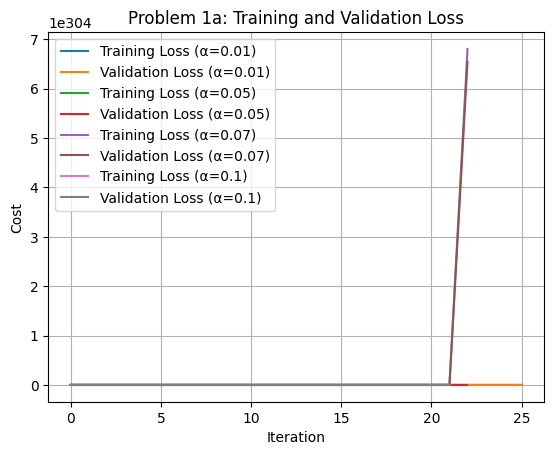

In [ ]:
# Problem 1a: Training model

rates = [0.01, .05, .07, .1]
iterations = 1000

for alpha in rates:

  # Reset theta to zeros before training
  theta = np.zeros(X_train.shape[1])
  theta_final, train_cost, test_cost = gradient_descent(
    X_train,
    y_train,
    X_test,
    y_test,
    theta,
    alpha,
    iterations
    )

  # Find iterations before loss becomes infinite or NaN
  valid = np.isfinite(train_cost) & np.isfinite(test_cost)

  # Plot training and validation loss for this learning rate
  plt.plot(
      np.arange(iterations)[valid],
      train_cost[valid],
      label=f'Training Loss (α={alpha})'
  )

  plt.plot(
      np.arange(iterations)[valid],
      test_cost[valid],
      label=f'Validation Loss (α={alpha})'
  )

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 1a: Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()




In [ ]:
# Problem 1b

# Convert yes/no variables to 1/0
varlist = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

df[varlist] = df[varlist].apply(binary_map)

In [ ]:
# Select input variables for Problem 1b
features_1b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_1b = df[features_1b].to_numpy(dtype=float)
y_1b = df['price'].to_numpy(dtype=float)

In [ ]:
# Add column of ones for theta_0
X_0 = np.ones((len(y_1b), 1))

X_1b = np.hstack((X_0, X_1b))

# Initialize 12 theta values:
# 1 bias + 11 input variables
theta_1b = np.zeros(X_1b.shape[1])

print(X_1b[:5])
print(theta_1b)

[[1.00e+00 7.42e+03 4.00e+00 2.00e+00 3.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 1.00e+00 2.00e+00 1.00e+00]
 [1.00e+00 8.96e+03 4.00e+00 4.00e+00 4.00e+00 1.00e+00 0.00e+00 0.00e+00
  0.00e+00 1.00e+00 3.00e+00 0.00e+00]
 [1.00e+00 9.96e+03 3.00e+00 2.00e+00 2.00e+00 1.00e+00 0.00e+00 1.00e+00
  0.00e+00 0.00e+00 2.00e+00 1.00e+00]
 [1.00e+00 7.50e+03 4.00e+00 2.00e+00 2.00e+00 1.00e+00 0.00e+00 1.00e+00
  0.00e+00 1.00e+00 3.00e+00 1.00e+00]
 [1.00e+00 7.42e+03 4.00e+00 1.00e+00 2.00e+00 1.00e+00 1.00e+00 1.00e+00
  0.00e+00 1.00e+00 2.00e+00 0.00e+00]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
X_train_1b, X_test_1b, y_train_1b, y_test_1b = train_test_split(
    X_1b,
    y_1b,
    test_size=0.2,
    random_state=15
)

print("Training examples:", len(y_train_1b))
print("Testing examples:", len(y_test_1b))

Training examples: 436
Testing examples: 109


/tmp/ipykernel_947/89974871.py:18: RuntimeWarning: overflow encountered in square
  sqrErrors = np.square(errors)
/tmp/ipykernel_947/2095088809.py:27: RuntimeWarning: invalid value encountered in subtract
  theta -= sum_delta


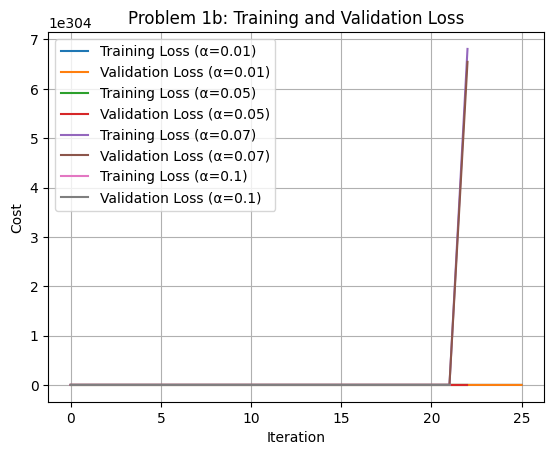

In [ ]:
# Problem 1b gradient

rates = [0.01, .05, .07, .1]
iterations = 1000

for alpha in rates:

  # Reset theta to zeros before training
  theta = np.zeros(X_train_1b.shape[1])
  theta_final, train_cost, test_cost = gradient_descent(
    X_train_1b,
    y_train_1b,
    X_test_1b,
    y_test_1b,
    theta,
    alpha,
    iterations
    )

  # Find iterations before loss becomes infinite or NaN
  valid = np.isfinite(train_cost) & np.isfinite(test_cost)

  # Plot training and validation loss for this learning rate
  plt.plot(
      np.arange(iterations)[valid],
      train_cost[valid],
      label=f'Training Loss (α={alpha})'
  )

  plt.plot(
      np.arange(iterations)[valid],
      test_cost[valid],
      label=f'Validation Loss (α={alpha})'
  )

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 1b: Training and Validation Loss')
plt.legend()
plt.grid()

plt.show()




In [ ]:
# Problem 2a - Input Normalization

minmax_scaler = MinMaxScaler()

X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

# Fit scaler using training data only
X_train_norm[:, 1:] = minmax_scaler.fit_transform(X_train[:, 1:])

# Apply same scaling to testing data
X_test_norm[:, 1:] = minmax_scaler.transform(X_test[:, 1:])

In [ ]:
print("Original training data:")
print(X_train[:5])

print("\nNormalized training data:")
print(X_train_norm[:5])

Original training data:
[[1.000e+00 4.600e+03 4.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 3.900e+03 3.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 4.500e+03 3.000e+00 1.000e+00 4.000e+00 0.000e+00]
 [1.000e+00 3.630e+03 3.000e+00 1.000e+00 2.000e+00 2.000e+00]
 [1.000e+00 4.075e+03 3.000e+00 1.000e+00 1.000e+00 2.000e+00]]

Normalized training data:
[[1.         0.20274914 0.6        0.         0.33333333 0.        ]
 [1.         0.15463918 0.4        0.         0.33333333 0.        ]
 [1.         0.19587629 0.4        0.         1.         0.        ]
 [1.         0.13608247 0.4        0.         0.33333333 0.66666667]
 [1.         0.16666667 0.4        0.         0.         0.66666667]]


Learning rate: 0.01
Final training cost: 948785984582.353
Final validation cost: 997684748701.6493

Learning rate: 0.05
Final training cost: 785047312930.4045
Final validation cost: 837117297475.8536

Learning rate: 0.07
Final training cost: 767806495033.8232
Final validation cost: 827205237872.5981

Learning rate: 0.1
Final training cost: 758135946038.4553
Final validation cost: 824750411960.9304



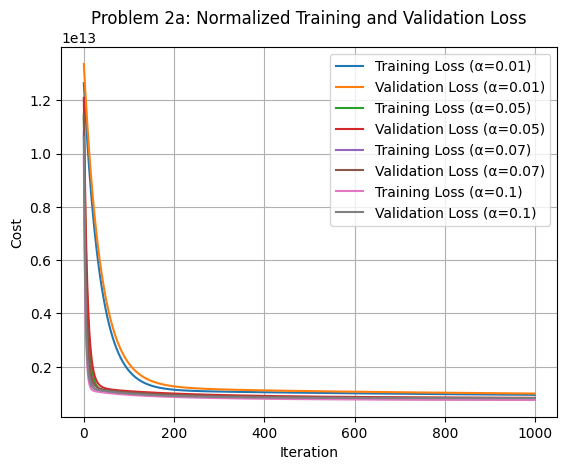

In [ ]:
# Problem 2a: Gradient descent with normalized inputs

rates = [0.01, 0.05, 0.07, 0.1]
iterations = 1000

for alpha in rates:

    # Reset theta to zeros before each training
    theta = np.zeros(X_train_norm.shape[1])

    theta_final, train_cost, test_cost = gradient_descent(
        X_train_norm,
        y_train,
        X_test_norm,
        y_test,
        theta,
        alpha,
        iterations
    )

    # Plot training and validation loss
    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (α={alpha})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (α={alpha})'
    )
    print(f"Learning rate: {alpha}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()


plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 2a: Normalized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Problem 2a: Input Standardization

standard_scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

# Standardize input variables only
X_train_std[:, 1:] = standard_scaler.fit_transform(X_train[:, 1:])
X_test_std[:, 1:] = standard_scaler.transform(X_test[:, 1:])

In [ ]:
print("Original training data:")
print(X_train[:5])

print("\nStandardized training data:")
print(X_train_std[:5])

Original training data:
[[1.000e+00 4.600e+03 4.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 3.900e+03 3.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 4.500e+03 3.000e+00 1.000e+00 4.000e+00 0.000e+00]
 [1.000e+00 3.630e+03 3.000e+00 1.000e+00 2.000e+00 2.000e+00]
 [1.000e+00 4.075e+03 3.000e+00 1.000e+00 1.000e+00 2.000e+00]]

Standardized training data:
[[ 1.         -0.25733009  1.35467364 -0.56603947  0.23774408 -0.80764936]
 [ 1.         -0.57670751  0.01231521 -0.56603947  0.23774408 -0.80764936]
 [ 1.         -0.30295544  0.01231521 -0.56603947  2.59357177 -0.80764936]
 [ 1.         -0.69989594  0.01231521 -0.56603947  0.23774408  1.49388738]
 [ 1.         -0.49686315  0.01231521 -0.56603947 -0.94016977  1.49388738]]


Learning rate: 0.01
Final training cost: 753691783652.4545
Final validation cost: 831129670071.3989

Learning rate: 0.05
Final training cost: 753691302287.861
Final validation cost: 831217119255.9803

Learning rate: 0.07
Final training cost: 753691302287.861
Final validation cost: 831217119255.9841

Learning rate: 0.1
Final training cost: 753691302287.8608
Final validation cost: 831217119255.984



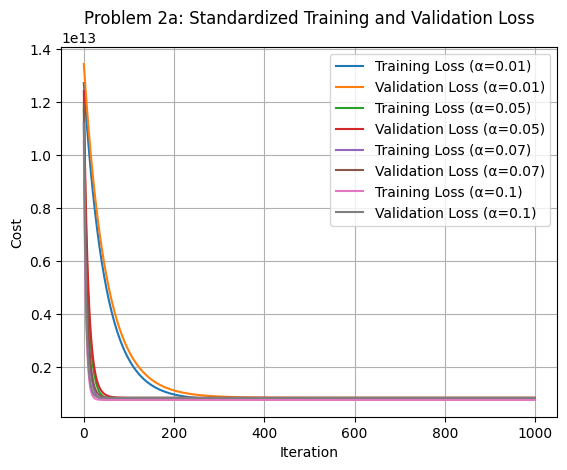

In [ ]:
# Problem 2a:  Gradient descent with standardized inputs

rates = [0.01, 0.05, 0.07, 0.1]
iterations = 1000

for alpha in rates:

    # Reset theta to zeros before each training
    theta = np.zeros(X_train_std.shape[1])

    theta_final, train_cost, test_cost = gradient_descent(
        X_train_std,
        y_train,
        X_test_std,
        y_test,
        theta,
        alpha,
        iterations
    )

    # Plot training and validation loss
    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (α={alpha})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (α={alpha})'
    )
    print(f"Learning rate: {alpha}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()


plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 2a: Standardized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Problem 2b: Input Normalization (more variables)


X_train_norm_2b = X_train_1b.copy()
X_test_norm_2b = X_test_1b.copy()

# Fit scaler using training data only
X_train_norm_2b[:, 1:] = minmax_scaler.fit_transform(X_train_1b[:, 1:])

# Apply same scaling to testing data
X_test_norm_2b[:, 1:] = minmax_scaler.transform(X_test_1b[:, 1:])

In [ ]:
print("Original training data:")
print(X_train_1b[:5])

print("\nNormalized training data:")
print(X_train_norm_2b[:5])

Original training data:
[[1.000e+00 4.600e+03 4.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 3.900e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 4.500e+03 3.000e+00 1.000e+00 4.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 3.630e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 4.075e+03 3.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00
  1.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00]]

Normalized training data:
[[1.         0.20274914 0.6        0.         0.33333333 1.
  0.         0.         0.         0.         0.         0.        ]
 [1.         0.15463918 0.4        0.         0.33333333 1.
  0.         0.         0.         0.         0.         0.        ]
 [1.         0.19587629 0.4        0.         1.         1.
  0. 

Learning rate: 0.01
Final training cost: 684403500382.4828
Final validation cost: 867010224181.2454

Learning rate: 0.05
Final training cost: 568936838017.7054
Final validation cost: 713105418823.5822

Learning rate: 0.07
Final training cost: 558177780300.63
Final validation cost: 700247263215.1273

Learning rate: 0.1
Final training cost: 551738672750.4808
Final validation cost: 693659418862.8671



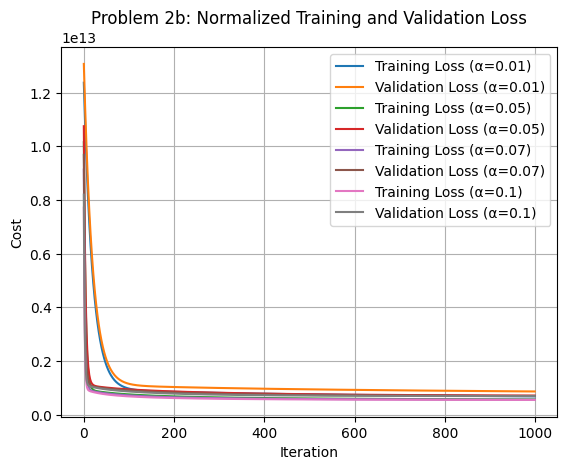

In [ ]:
# Problem 2b: Gradient descent with normalized inputs (more variables)

rates = [0.01, 0.05, 0.07, 0.1]
iterations = 1000

for alpha in rates:

    # Reset theta to zeros before each training
    theta = np.zeros(X_train_norm_2b.shape[1])

    theta_final, train_cost, test_cost = gradient_descent(
        X_train_norm_2b,
        y_train_1b,
        X_test_norm_2b,
        y_test_1b,
        theta,
        alpha,
        iterations
    )

    # Plot training and validation loss
    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (α={alpha})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (α={alpha})'
    )
    print(f"Learning rate: {alpha}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()


plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 2b: Normalized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Problem 2b: Input Standardization (more variables)



X_train_std_2b = X_train_1b.copy()
X_test_std_2b = X_test_1b.copy()

# Standardize input variables only
X_train_std_2b[:, 1:] = standard_scaler.fit_transform(X_train_1b[:, 1:])
X_test_std_2b[:, 1:] = standard_scaler.transform(X_test_1b[:, 1:])

In [ ]:
print("Original training data:")
print(X_train_1b[:5])

print("\nStandardized training data:")
print(X_train_std_2b[:5])

Original training data:
[[1.000e+00 4.600e+03 4.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 3.900e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 4.500e+03 3.000e+00 1.000e+00 4.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 3.630e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 4.075e+03 3.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00
  1.000e+00 0.000e+00 0.000e+00 2.000e+00 0.000e+00]]

Standardized training data:
[[ 1.         -0.25733009  1.35467364 -0.56603947  0.23774408  0.41097543
  -0.44104484 -0.71686044 -0.22494979 -0.67330033 -0.80764936 -0.54200419]
 [ 1.         -0.57670751  0.01231521 -0.56603947  0.23774408  0.41097543
  -0.44104484 -0.71686044 -0.22494979 -0.67330033 -0.80764936 -0.54200419]
 [ 1.         -0.302955

Learning rate: 0.01
Final training cost: 548244213765.77356
Final validation cost: 692828875973.7695

Learning rate: 0.05
Final training cost: 548241777203.5849
Final validation cost: 693199673591.6222

Learning rate: 0.07
Final training cost: 548241777203.5849
Final validation cost: 693199673607.5164

Learning rate: 0.1
Final training cost: 548241777203.5849
Final validation cost: 693199673607.5194



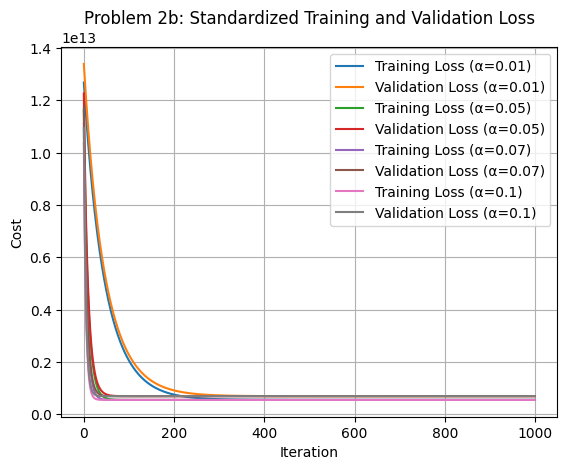

In [ ]:
# Problem 2b: Gradient descent with standardized inputs (more variables)

rates = [0.01, 0.05, 0.07, 0.1]
iterations = 1000

for alpha in rates:

    # Reset theta to zeros before each training
    theta = np.zeros(X_train_std_2b.shape[1])

    theta_final, train_cost, test_cost = gradient_descent(
        X_train_std_2b,
        y_train_1b,
        X_test_std_2b,
        y_test_1b,
        theta,
        alpha,
        iterations
    )

    # Plot training and validation loss
    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (α={alpha})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (α={alpha})'
    )
    print(f"Learning rate: {alpha}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()


plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 2b: Standardized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
def gradient_descent_regularized(
    X_train, y_train, X_test, y_test,
    theta, alpha, iterations, lambda_
):
    m = len(y_train)

    train_cost_history = np.zeros(iterations)
    test_cost_history = np.zeros(iterations)

    for i in range(iterations):

        # Predictions and errors
        predictions = X_train.dot(theta)
        errors = predictions - y_train

        # Normal gradient
        gradient = (1 / m) * X_train.T.dot(errors)

        # L2 regularization gradient
        regularization = (lambda_ / m) * theta

        # Do NOT regularize theta_0 (bias)
        regularization[0] = 0

        # Update parameters
        theta = theta - alpha * (gradient + regularization)

        # Training cost with parameter penalty
        mse_cost = compute_cost(X_train, y_train, theta)

        penalty = (lambda_ / (2 * m)) * np.sum(theta[1:] ** 2)

        train_cost_history[i] = mse_cost + penalty

        # Evaluation cost WITHOUT penalty
        test_cost_history[i] = compute_cost(
            X_test, y_test, theta
        )

    return theta, train_cost_history, test_cost_history

Lambda: 0.01
Final training cost: 758574765386.236
Final validation cost: 824762402535.9131

Lambda: 0.1
Final training cost: 762497856526.5703
Final validation cost: 824884241680.6366

Lambda: 1
Final training cost: 799308491617.1641
Final validation cost: 827357051154.8312

Lambda: 10
Final training cost: 1029365231599.8871
Final validation cost: 907796585131.295



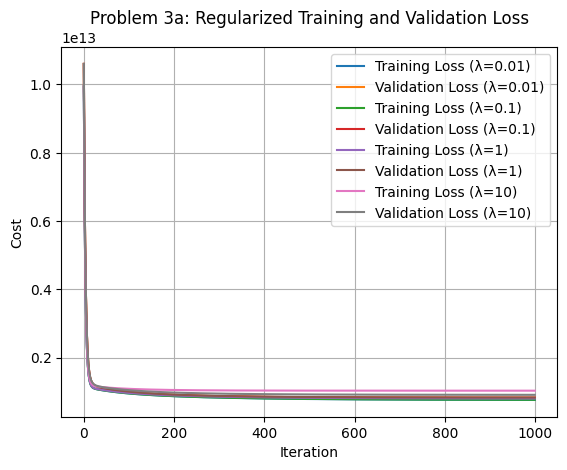

In [ ]:
# Problem 3a: Regularization
# using normalization
alpha = 0.1
iterations = 1000

lambdas = [0.01, 0.1, 1, 10]

for lambda_ in lambdas:

    theta = np.zeros(X_train_norm.shape[1])

    theta_final, train_cost, test_cost = gradient_descent_regularized(
        X_train_norm,
        y_train,
        X_test_norm,
        y_test,
        theta,
        alpha,
        iterations,
        lambda_
    )

    print(f"Lambda: {lambda_}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()

    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (λ={lambda_})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (λ={lambda_})'
    )

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 3a: Regularized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

Lambda: 0.01
Final training cost: 548255027653.2659
Final validation cost: 693197135443.2838

Lambda: 0.1
Final training cost: 548374264138.5612
Final validation cost: 693174318397.2383

Lambda: 1
Final training cost: 549564894415.9216
Final validation cost: 692948753230.6991

Lambda: 10
Final training cost: 561301643810.6807
Final validation cost: 690942719067.042



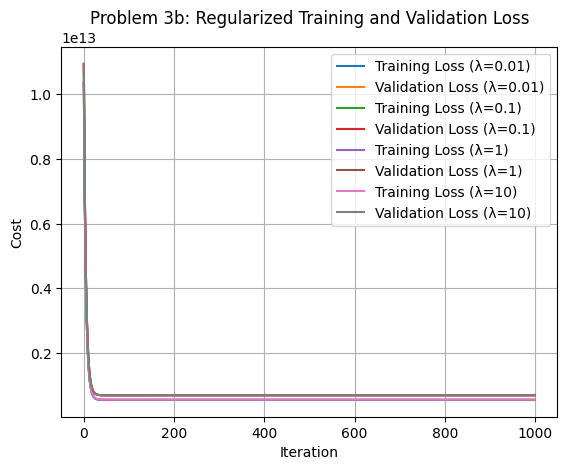

In [ ]:
# Problem 3b: Regularization (more variables)
# using standardization
alpha = 0.1
iterations = 1000

lambdas = [0.01, 0.1, 1, 10]

for lambda_ in lambdas:

    theta = np.zeros(X_train_std_2b.shape[1])

    theta_final, train_cost, test_cost = gradient_descent_regularized(
        X_train_std_2b,
        y_train_1b,
        X_test_std_2b,
        y_test_1b,
        theta,
        alpha,
        iterations,
        lambda_
    )

    print(f"Lambda: {lambda_}")
    print(f"Final training cost: {train_cost[-1]}")
    print(f"Final validation cost: {test_cost[-1]}")
    print()

    plt.plot(
        np.arange(iterations),
        train_cost,
        label=f'Training Loss (λ={lambda_})'
    )

    plt.plot(
        np.arange(iterations),
        test_cost,
        label=f'Validation Loss (λ={lambda_})'
    )

plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Problem 3b: Regularized Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()